![CFD.ML v.20](<./script_lib/CFD.ML v2.0.png>)

CFD.ML is delivered via DNV WindFarmer's web API. It is a machine learning model that can predict turbine interaction loss factors, both wake and blockage correction losses together. Find out more in the [WindFarmer documentation](https://myworkspace.dnv.com/download/public/renewables/windfarmer/manuals/latest/CalcRef/TurbineInteractions/CFDML/CFDML.html).

With this notebook you can:
1. import the wind farm data model as a json file, exported from WindFarmer, or converted from Openwind json or other formats.
1. define calculation settings
1. run the calculation and diagnose errors
1. interogate and visualise the results, comparing them to those from traditional engineering models. 

In [1]:
import os
import json
import time
import pandas as pd
from matplotlib import pyplot as plt
from copy import deepcopy
from script_lib import cfdml_v2
from script_lib import api_calls
from script_lib import aep_results


Set the project name and location

In [2]:
projectId= "TheBowl"
siteLatitude= 51.5
siteLongitude= 1.3

# Import the API inputs as a json file
The easiest and most reliable way to web API inputs is via the WindFarmer desktop application. 
Export the annual energy production calculation API input settings from within your workbook using an in-app script. Edit the file path and call:

```Toolbox.ExportWindFarmerEnergyJson( @"C:\folder\my_aep_calculation_inputs.json" );```

If you wish to construct the inputs yourself, see the datamodel described in our [API documentation and OpenAPI specification](https://myworkspace.dnv.com/download/public/renewables/windfarmer/manuals/latest/WebAPI/Introduction/Introduction.html). 

Download the atmospheric conditions presets from [here](https://mysoftware.dnv.com/download/renewables/windfarmer/Downloads/cfdml_preset_atmospheric_conditions.json) [login with veracity account] and save it in this folder, or specify the `atmospheric_conditions_presets_file_path` to the downloaded JSON file below.

We can also asist with a script to convert the workbook JSON file exported from OpenWind to the WindFarmer format.

In [3]:
# Set input data folder, paths relative to this notebook
input_folder = './input_data'
cfdml_folder = './api_io' # for interemediate inputs and results created here
if not os.path.exists(cfdml_folder):
    os.makedirs(cfdml_folder)

In [4]:
# Export AEP input settings from your Windfarmer workbook using an in-app script and calling Toolbox.ExportWindFarmerEnergyJson( input_data_file_path ):
input_json_file_path = os.path.join(input_folder, 'TheBowl_with_neighbours_api_inputs_from_wfa_desktop.json')

# set the below if you have site-specific atmospheric conditions that you want to use in the AEP calculation, 
# otherwise leave as None to get the default conditions from the atmospheric conditions API.
atmospheric_conditions_file_path = None # os.path.join(input_folder, 'my_site_specific_atmospheric_conditions.json')

# Save cfdml inputs and outputs in one folder
inputs_file_name = os.path.join(cfdml_folder, f'cfdmlv2api_inputs_{projectId}.json')
results_file_name = os.path.join(cfdml_folder, f'cfdmlv2api_results_{projectId}.json')
results_file_name_no_neighbours = os.path.join(cfdml_folder, f'cfdmlv2api_no_neighbours_results_{projectId}.json')
per_turbine_results_file_name = os.path.join(cfdml_folder, f'cfdmlv2api_per_turbine_results_{projectId}.csv')

# project Info:
projectInfo = { "projectId":projectId,
                "siteLatitude": siteLatitude,
                "siteLongitude": siteLongitude
                } 

### load the workbook JSON inputs

The project contains 110 turbines accross 2 wind farms


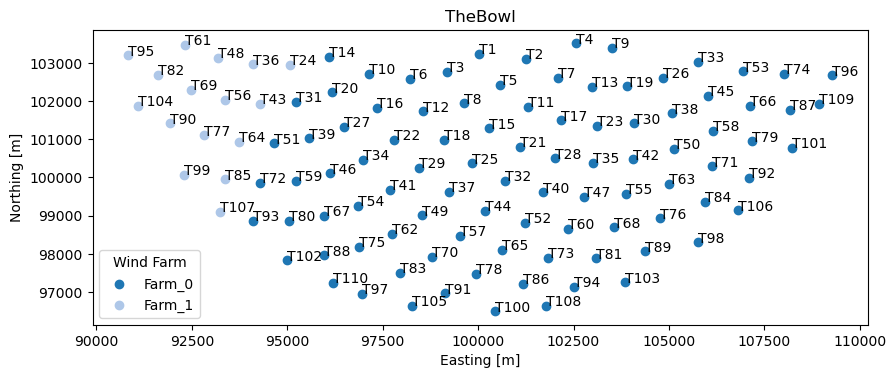

In [5]:
with open(input_json_file_path) as f:
    json_string = f.read()
    json_input = json.loads(json_string)
# Assign a color to each wind farm
farm_names = [farm["windFarmName"] if "windFarmName" in farm else f"Farm_{i}" for i, farm in enumerate(json_input["windFarms"])]
color_map = plt.get_cmap('tab20')
farm_colors = {name: color_map(i % 20) for i, name in enumerate(farm_names)}

turbines = []
for farm, farm_name in zip(json_input["windFarms"], farm_names):
    for turbine in farm["turbines"]:
        new_turbine = deepcopy(turbine)
        new_turbine["farm_name"] = farm_name
        turbines.append(new_turbine)
number_of_turbines = len(turbines)
print(f'The project contains {number_of_turbines} turbines accross {len(json_input["windFarms"])} wind farms')

fig1, ax = plt.subplots(figsize=(10,7))
for wt in turbines:
    color = farm_colors[wt["farm_name"]]
    ax.scatter(wt['location']['easting_m'], wt['location']['northing_m'], c=[color], label=wt["farm_name"])
    ax.set_xlabel("Easting [m]")
    ax.set_ylabel("Northing [m]")
    ax.set_aspect('equal', adjustable='box')
    ax.annotate(wt['name'], [wt['location']['easting_m'], wt['location']['northing_m']])
ax.set_title(f'{projectId}')

# Add legend with unique farm names
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Wind Farm")



# Choose model inputs 

**Note**: the part responsible for model settings in the input jsons contained in the ```input_json_file_path```  will get overwritten by the settings specified

In [6]:
# specify the desired model combination
WAKE_MODEL_CHOICE = "CFDML" # EddyViscosity/ModifiedPark/TurbOPark/CFDML    # Note CFDML wakes calculates the full TILF (wakes + blockage)
BLOCKAGE_MODEL_CHOICE = "CFDML" # BEET/CFDML                                # Note if you choose CFDML wakes, you can only choose CFD.ML blockage. 
CALCULATE_EFFICIENCIES = True #True/False                                   # Calculating efficiencies gives you a full breakdown of wakes, blockage, neighbour wakes etc. but takes longer to compute
CFDML_VERSION = "2.6.0"
BLOCKAGE_APPLICATION_METHOD = "OnWindSpeed" # OnWindSpeed / OnEnergy
NUMBER_OF_DIRECTION_STEPS = 180

# For WAKE_MODEL_CHOICE = CFD.ML  we currently reccomend not applying any large wind farm correction in by-wind-speed extrapolation of CFD.ML results.
EXTRAPOLATE_CFDML_USING_LARGE_WIND_FARM_CORRECTION = False # True/False

# Should you wish to use this notebook with a WAKE_MODEL_CHOICE of EddyViscosity, 
# you should define your large wind farm correction settings 
# The below values are defaults for an offshore project
lwf_parameters = { 
                    "baseRoughnessZ01": 0.0004,
                    "increasedRoughnessZ02": 0.0192,
                    "geometricWidthDiameters": 1.0,
                    "recoveryStartDiameters": 120.0,
                    "fiftyPercentRecoveryDiameters": 40.0
                }

# Or get this from your input json if you have already defined it there:
# lwf_paramters = json_input["energyEfficienciesSettings"]["wakeModel"]["eddyViscosity"]["largeWindFarmCorrectionParameters"]

## API setup
To access the API you need a authorization token. 
This should be kept secure - and not added to source control, so I'm getting it from an environment variable. See setup instructions for saving your access key as an environment variable documented [here.](https://myworkspace.dnv.com/download/public/renewables/windfarmer/manuals/latest/WebAPI/Introduction/gettingStarted.html)

In [7]:
api_url = 'https://windfarmer.uat.dnv.com/api/v3/'
auth_token = os.environ['WINDFARMER_UAT_KEY']

# The token should be passed as an Authorization header.
#  We also need to set the `Content-Type` to let the API know that we're sending JSON data.

wf_api = api_calls.WindFarmerAPI(auth_token, api_url)

Response from Status: 200
Connection to DNV WindFarmer Services API was successful. You are ready to run calculations!
  WindFarmer API version = 3.2.0
  Calculations version = 3.0.15.0


## 1. Atmospheric Conditions classification for the site
Performs site classification and returns atmospheric condition data compatible with WindFarmer turbine interaction modeling applications.

Endpoint: GET /api/v3/AtmosphericConditions

This will define a stablity rose, with the proportion of conditions in each class for each direction sector

In [8]:
if atmospheric_conditions_file_path is not None:
    with open(atmospheric_conditions_file_path) as f:
        atmosphericConditions = json.load(f)
        print("Loaded atmospheric conditions fromfile")
else:
    site_params = {
        "lat": siteLatitude,          # Latitude in decimal degrees (-85 to 85)
        "lon": siteLongitude,         # Longitude in decimal degrees (-180 to 180)
        "radiusKm": 50.0,     # Analysis radius in km (0.1-100, default: 50.0)
        "landFractionThreshold": 0.2  # Threshold for land classification (0.0-1.0, default: 0.2)
    }

    site_classification = wf_api.get_atmospheric_conditions(**site_params)
    atmosphericConditions = site_classification["atmosphericConditions"]

Response from AtmosphericConditions: 200
Site Classification metadata:
{
  "siteLatitude": 51.5,
  "siteLongitude": 1.3,
  "nearestEra5GridLatitude": 51.5,
  "nearestEra5GridLongitude": 1.25,
  "distanceToNearestGridPoint_km": 3.4610234005411282,
  "numberOfSectors": 12,
  "coastlineDetectionRadius_km": 50,
  "stabilityClassificationMethod": "blend",
  "era5TimeSeriesStartDate": "2023-01-01",
  "era5TimeSeriesEndDate": "2024-12-31"
}


atmospheric condition probability distrbution:
Atmospheric condition probability distribution:

Distinct atmospheric conditions classes to simulate:
 ['north_sea_stable_wrf', 'north_sea_unstable_wrf', 'north_sea_stable_offland_wrf', 'north_sea_unstable_offland_wrf']
✓ Plot saved to atmospheric_stability_rose.png (300 DPI)


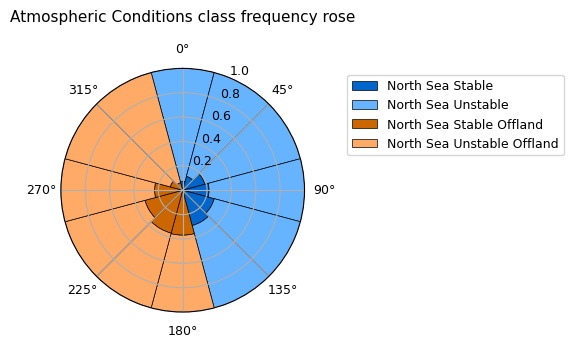


✓ Stability rose plot created successfully

Atmospheric Condition Distribution Table:


,fromDirection_degrees,toDirection_degrees,atmosphericConditionClassIds,probabilityForClasses
0,345,15,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.071605, 0.928395]"
1,15,45,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.117722, 0.882278]"
2,45,75,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.188679, 0.811321]"
3,75,105,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.216357, 0.783643]"
4,105,135,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.267937, 0.732063]"
5,135,165,"[north_sea_stable_wrf, north_sea_unstable_wrf]","[0.300334, 0.699666]"
6,165,195,"[north_sea_stable_offland_wrf, north_sea_unsta...","[0.36918, 0.6308199999999999]"
7,195,225,"[north_sea_stable_offland_wrf, north_sea_unsta...","[0.364958, 0.635042]"
8,225,255,"[north_sea_stable_offland_wrf, north_sea_unsta...","[0.320439, 0.6795610000000001]"
9,255,285,"[north_sea_stable_offland_wrf, north_sea_unsta...","[0.230829, 0.769171]"


In [52]:
print("atmospheric condition probability distrbution:" )
cfdml_v2.plot_atmospheric_conditions_rose(atmosphericConditions['atmosphericConditionProbabilityDistribution'])
pd.DataFrame(atmosphericConditions['atmosphericConditionProbabilityDistribution'])

The training has been performed over a wide range of wind farms and atmospheric conditions as can be seen in the plots below.
| Wind farm parameters | Atmopsheric conditions |
|-|-|
|![alt text](./script_lib/trainingset_metadata.png) |![alt text](./script_lib/trainingset_metadata_atmos.png)|

In [53]:
# Import utility functions
from script_lib.input_json_prep import (
    set_model_settings, 
    switch_off_fpm_export, 
    configure_fpm_export,
)

# Defining the model inputs
set_model_settings(
    json_input,
    wake_model_choice=WAKE_MODEL_CHOICE,
    blockage_model_choice=BLOCKAGE_MODEL_CHOICE,
    calculate_efficiencies=CALCULATE_EFFICIENCIES,
    number_of_direction_steps=NUMBER_OF_DIRECTION_STEPS,
    cfdml_version=CFDML_VERSION,
    blockage_application_method=BLOCKAGE_APPLICATION_METHOD, 
    lwf_parameters= lwf_parameters,
    lwf_used_in_wind_speed_extrapolation = EXTRAPOLATE_CFDML_USING_LARGE_WIND_FARM_CORRECTION,
)

switch_off_fpm_export(json_input)
configure_fpm_export(json_input, wake_model_choice=WAKE_MODEL_CHOICE)  # activate wind speed fpms for the flow case visualisations

json_input["atmosphericConditions"] = atmosphericConditions
json_input["projectInfo"] = projectInfo

In [32]:
# write inputs to file
inputs_file_name = os.path.join(cfdml_folder, f'cfdmlv2apiinputs_{projectInfo["projectId"]}.json')
with open(inputs_file_name, 'w') as f:
    json.dump(json_input, f, indent=4, allow_nan=False)

### Call `AnnualEnergyProduction` endpoint to calculate results

Some methods to make a calls to the WFer Services API and compute the blockage correction regardless of approach.
We call the asynchronous AEP method for farms with > 150 turbines

In [33]:
api_response = await wf_api.call_aep_api( json_input)

Calling asynchronous AEP API
Response 202 - Accepted in 2.85s
...Job submitted with ID: 
911102f5-893b-4110-be51-34cee4502dc0
...Calculation status @ 12.40s: RUNNING - 0.0% - Starting calculation
...Calculation status @ 42.03s: RUNNING - 10.0% - Calculating Full Yield - Setting up calculation
...Calculation status @ 74.74s: RUNNING - 10.0% - Calculating Full Yield - Calculating AEP for direction 0 of 180
...Calculation status @ 106.97s: RUNNING - 10.0% - Calculating LWFModel Yield - Setting up calculation
...Calculation status @ 149.89s: RUNNING - 98.00000000000001% - Calculating BlockageOn Yield - Calculating AEP for direction 198 of 180
...Calculation status @ 210.71s: SUCCESS - 100.0% - Calculation complete
SUCCESS in 240.36s


In [34]:
# # If want to try getting results after interupting the script, 
# # you can uncomment the below, enter your job ID printed above, then try and get the results

# job_id = "289953d4-09b1-43cb-acaf-7b36c97854e7"
# status, api_response = await wf_api.poll_for_status(job_id)

Write results to file


In [35]:
with open(results_file_name, 'w') as f:
    f.write(json.dumps(api_response, indent=4))

time.sleep(1)

# Review results
### Report Gross + Full AEP + Wake + Blockage loss factors

Read results back in from file (in case you wish to run plotting and reporting again without recalculation )

In [36]:
with open(results_file_name, 'r') as f:
    results = json.load(f)

Headline results

In [37]:
results_processor = aep_results.AEPResultsProcessor(json_input, results)
results_summary_df = results_processor.get_results_summary_df()
results_summary_df.T

,Farm
Calculation settings,"Wakes: CFDML, Blockage: CFDML, Blockage applic..."
Gross Yield [GWh/Annum],1377.581151
Total turbine interaction efficiency [%],81.323081
Total turbine interaction efficiency - internal farms only [%],82.942798
Internal blockage efficiency [%],95.310571
Internal wake efficiency [%],87.023713
Total turbine interaction efficiency - impact of external farms [%],98.047188
External blockage efficiency [%],99.799986
External wake efficiency [%],98.243689
Alternative breakdown:,"Total wakes and blockage components, with impa..."


Note:
* Total turbine interaction efficiency = blockage * internal_wake * external_wake
* The total losses can also include hysteresis and curtailment efficiencies, depending on the chosen calculation settings

## Pattern of production
The annual energy production pattern accross the farm

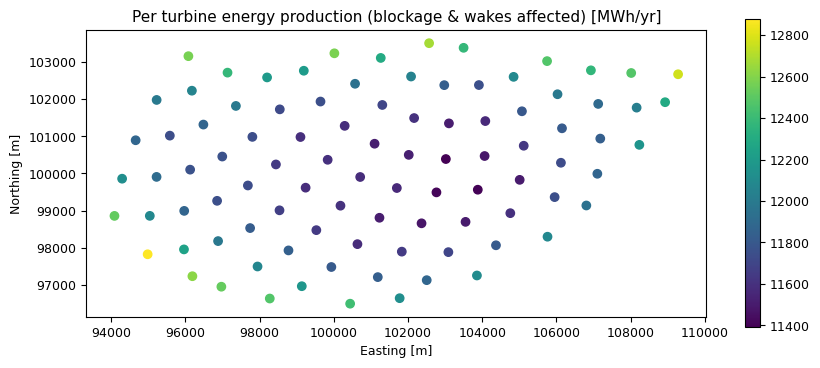

In [38]:
# Pattern of production - Full yield
per_turbine_results = pd.DataFrame.from_dict(results['windFarmAepOutputs'][0]['turbineResults'])
per_turbine_results.set_index('turbineName', drop=True, inplace=True)
per_turbine_results['easting'] = per_turbine_results['turbineLocation'].map(lambda x: dict(x)['easting_m'])
per_turbine_results['northing'] = per_turbine_results['turbineLocation'].map(lambda x: dict(x)['northing_m'])
fig, ax = plt.subplots(figsize=(10,4))
im = ax.scatter(per_turbine_results['easting'], per_turbine_results['northing'], c=per_turbine_results['fullAnnualYield_MWh_per_year'], cmap='viridis')
ax.set_title("Per turbine energy production (blockage & wakes affected) [MWh/yr]")
ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")
ax.set_aspect('equal', adjustable='box')
fig.colorbar(im)

In [39]:
turbine_results_df = pd.DataFrame.from_dict(results['windFarmAepOutputs'][0]['turbineResults'])
turbine_results_df.set_index('turbineName', drop=True, inplace=True)
turbine_results_df["farm_name"] = results['windFarmAepOutputs'][0]['windFarmName']
turbine_results_df['easting'] = per_turbine_results['turbineLocation'].map(lambda x: dict(x)['easting_m'])
turbine_results_df['northing'] = per_turbine_results['turbineLocation'].map(lambda x: dict(x)['northing_m'])
turbine_results_df["turbineInteractionEfficiency"] = per_turbine_results["fullAnnualYield_MWh_per_year"] / per_turbine_results["grossAnnualYield_MWh_per_year"]
turbine_results_df.drop(columns=['turbineLocation', 'usedPerformanceTableIds'], inplace=True)
turbine_results_df.to_csv(per_turbine_results_file_name)
turbine_results_df

,grossAnnualYield_MWh_per_year,internalBlockageOnAnnualYield_MWh_per_year,blockageOnAnnualYield_MWh_per_year,internalWakesOnAnnualYield_MWh_per_year,hysteresisAdjustmentOnAnnualYield_MWh_per_year,largeWindFarmCorrectionOnAnnualYield_MWh_per_year,neighborsWakesOnAnnualYield_MWh_per_year,fullAnnualYield_MWh_per_year,freeMeanWindSpeed_m_per_s,fullMeanWindSpeed_m_per_s,ambientMeanTurbulenceIntensity_percentage,fullMeanTurbulenceIntensity_percentage,airDensityAtHubHeight_kg_per_m3,farm_name,easting,northing,turbineInteractionEfficiency
turbineName,,,,,,,,,,,,,,,,,
T1,14655.118623,13947.354064,13926.732739,12762.636148,12762.636148,12762.636148,12575.384444,12575.384444,7.343395,6.804536,7.5,8.173521,1.225,Farm,100016.05320,103237.74590,0.858088
T2,14655.118623,13937.344771,13907.599872,12478.654364,12478.654364,12478.654364,12289.925635,12289.925635,7.343395,6.727946,7.5,8.267013,1.225,Farm,101266.27330,103112.91200,0.838610
T3,14655.118623,13942.624562,13918.062783,12441.728839,12441.728839,12441.728839,12197.688395,12197.688395,7.343395,6.701331,7.5,8.311939,1.225,Farm,99192.44203,102767.81010,0.832316
T4,14655.118623,13956.959838,13937.727168,12792.039677,12792.039677,12792.039677,12675.664724,12675.664724,7.343395,6.830350,7.5,8.137875,1.225,Farm,102569.05990,103510.22970,0.864931
T5,14655.118623,13950.425222,13924.148854,12121.119022,12121.119022,12121.119022,11946.869524,11946.869524,7.343395,6.634328,7.5,8.392730,1.225,Farm,100573.65640,102416.78000,0.815201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T105,14655.118623,13965.715012,13932.806082,12625.160757,12625.160757,12625.160757,12473.085557,12473.085557,7.343395,6.765318,7.5,8.218826,1.225,Farm,98275.23922,96629.21760,0.851108
T106,14655.118623,13966.774024,13941.773050,12021.381864,12021.381864,12021.381864,11945.191166,11945.191166,7.343395,6.633182,7.5,8.377983,1.225,Farm,106806.64010,99136.60741,0.815087
T108,14655.118623,13958.866069,13932.262244,12207.793840,12207.793840,12207.793840,12118.973814,12118.973814,7.343395,6.672683,7.5,8.331682,1.225,Farm,101775.72030,96638.23162,0.826945


## TILF pattern for selected wind directions

In [40]:
# Select the wind direction and wind speed flow case you wish to review:
wind_direction = 0
wind_speed = 8.0

In [41]:
def get_atmos_classes_for_direction (wind_direction, atmosphericConditionProbabilityDistribution):
    for sector in atmosphericConditionProbabilityDistribution:
        to_direction = sector["toDirection_degrees"]
        from_direction = sector["fromDirection_degrees"]
        if  from_direction > to_direction :
            to_direction = to_direction + 360.0
            test_wind_direction = wind_direction + 360.0
        if (from_direction <= test_wind_direction and to_direction > wind_direction):
            classes_for_direction = sector["atmosphericConditionClassIds"]
            print(f"atmospheric conditions {classes_for_direction} found for wind direction {wind_direction}")
            return classes_for_direction
    print ("No atmospheric conditions found for wind direction!")
    return None

if WAKE_MODEL_CHOICE == "CFDML":
    atmos_classes_for_direction = get_atmos_classes_for_direction(wind_direction, site_classification['atmosphericConditions']['atmosphericConditionProbabilityDistribution'])
else: # FPM results are not split by atmospheric conditions
    atmos_classes_for_direction = ["Overall"]

atmospheric conditions ['north_sea_stable_wrf', 'north_sea_unstable_wrf'] found for wind direction 0


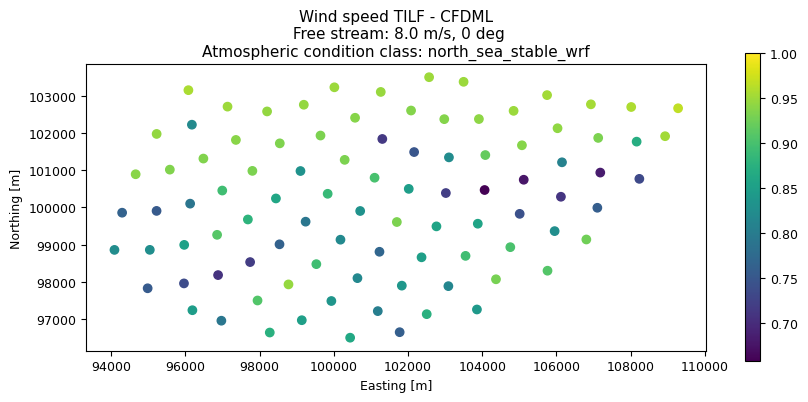

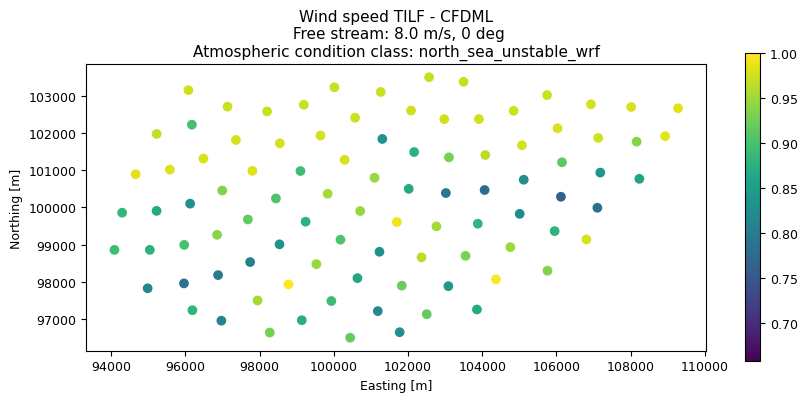

In [42]:
# wind speed turbine interaction loss factor plotting accross array
wind_direction_index = int(wind_direction/ (360.0 / NUMBER_OF_DIRECTION_STEPS))
wind_speed_index = int(wind_speed) # assuming integer wind speed steps.

waked_windspeed = pd.DataFrame(results['windFarmAepOutputs'][0]['turbineFlowAndPerformanceMatricesWithMastBinning'])
waked_windspeed.set_index('turbineName',drop=True, inplace=True)
for atmos_class in atmos_classes_for_direction:
    if WAKE_MODEL_CHOICE == "CFDML":
        waked_windspeed['WakedWindSpeed_m_per_s{}'.format(atmos_class)] = waked_windspeed['atmosphericConditionAwareWakedWindSpeed_m_per_s'].map(lambda x: x[atmos_class][wind_direction_index][wind_speed_index])
    else:
        waked_windspeed['WakedWindSpeed_m_per_s{}'.format(atmos_class)] = waked_windspeed['wakedWindSpeed_m_per_s'].map(lambda x: x[wind_direction_index][wind_speed_index])
# Plot
waked_windspeed['northing'] = per_turbine_results['northing']
waked_windspeed['easting'] = per_turbine_results['easting']

vmin = 1.0
for atmos_class in atmos_classes_for_direction:
    waked_windspeed['TILF {}'.format(atmos_class)] = waked_windspeed['WakedWindSpeed_m_per_s{}'.format(atmos_class)] / wind_speed
    bl_vmin = waked_windspeed['TILF {}'.format(atmos_class)].min()
    if bl_vmin < vmin:
        vmin = bl_vmin
for atmos_class in atmos_classes_for_direction:
    fig3, ax3 = plt.subplots(figsize=(10,4))
    im2 = ax3.scatter(waked_windspeed['easting'], waked_windspeed['northing'], c=waked_windspeed['TILF {}'.format(atmos_class)], cmap='viridis', vmin=vmin, vmax=1.0)
    fig3.colorbar(im2)
    if WAKE_MODEL_CHOICE == "CFDML":
        title = f"Wind speed TILF - {WAKE_MODEL_CHOICE}\n Free stream: {wind_speed} m/s, {wind_direction} deg\nAtmospheric condition class: {atmos_class}"        
    else:   
        title = f"Wind speed TILF - {WAKE_MODEL_CHOICE} with {BLOCKAGE_MODEL_CHOICE} blockage correction \n Free stream: {wind_speed} m/s, {wind_direction} deg\nAtmospheric condition class: {atmos_class}"
    ax3.set_title(title)
    ax3.set_xlabel("Easting [m]")
    ax3.set_ylabel("Northing [m]")
    ax3.set_aspect('equal', adjustable='box')

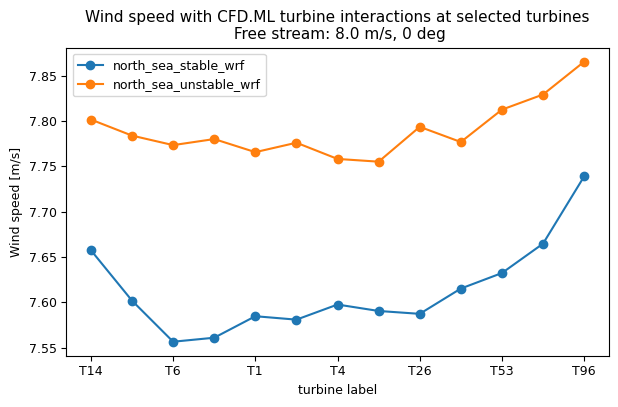

In [43]:
# Plot wind speed pattern for user specified turbines
northern_edge = [  'T14', 'T10', 'T6', 'T3', 'T1', 'T2', 'T4', 'T9', 'T26', 'T33', 'T53', 'T74', 'T96']

fig, ax = plt.subplots(figsize=(7,4))
for atmos_class in atmos_classes_for_direction:
    (waked_windspeed.loc[northern_edge]['WakedWindSpeed_m_per_s{}'.format(atmos_class)]).plot(marker='o', ax=ax )
    handles, labels = ax.get_legend_handles_labels()
    if WAKE_MODEL_CHOICE == "CFDML":
        ax.set_title(f'Wind speed with CFD.ML turbine interactions at selected turbines\n Free stream: {wind_speed} m/s, {wind_direction} deg')
    else:   
        ax.set_title(f'Wind speed with {WAKE_MODEL_CHOICE} wakes with a \n {BLOCKAGE_MODEL_CHOICE} blockage correction at selected turbines\n Free stream: {wind_speed} m/s, {wind_direction} deg')
    ax.set_ylabel('Wind speed [m/s]')
    ax.set_xlabel('turbine label')
ax.legend(handles, atmos_classes_for_direction)